In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA

from prophet import Prophet


In [5]:
data = pd.read_csv("/OnlineRetail.csv", encoding="latin1")

data = data.dropna(subset=["CustomerID"])
data = data.drop_duplicates()
data["InvoiceNo"] = data["InvoiceNo"].astype(str)
data = data[data["InvoiceNo"].str.startswith("C") == False]
data = data[data["Quantity"] > 0]
data = data[data["UnitPrice"] > 0]
data["CustomerID"] = data["CustomerID"].astype(int).astype(str)
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]

print("Cleaned shape:", data.shape)
data.head()

Cleaned shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [6]:
iso_features = data[["Quantity", "UnitPrice", "TotalPrice"]]

iso_model = IsolationForest(contamination=0.01, random_state=42)
data["anomaly"] = iso_model.fit_predict(iso_features)   # -1 = anomaly, 1 = normal

n_anomalies = (data["anomaly"] == -1).sum()
print("Total anomalies found:", n_anomalies, "out of", len(data), "rows")


Total anomalies found: 3922 out of 392692 rows


In [7]:
anomalies = data[data["anomaly"] == -1]
anomalies[["Quantity", "UnitPrice", "TotalPrice"]].describe()

,Quantity,UnitPrice,TotalPrice
count,3922.000000,3922.000000,3922.000000
mean,281.256502,30.691402,527.831181
std,1777.633855,218.850102,3061.718838
min,1.000000,0.040000,17.280000
25%,60.000000,1.250000,212.120000
50%,192.000000,2.550000,306.000000
75%,288.000000,7.400000,483.840000
max,80995.000000,8142.750000,168469.600000


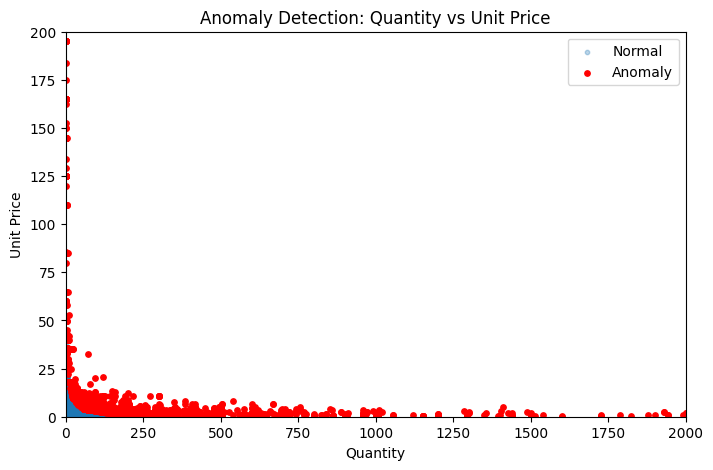

In [8]:
plt.figure(figsize=(8,5))
normal_points = data[data["anomaly"] == 1]
anomaly_points = data[data["anomaly"] == -1]

plt.scatter(normal_points["Quantity"], normal_points["UnitPrice"],
            alpha=0.3, label="Normal", s=10)
plt.scatter(anomaly_points["Quantity"], anomaly_points["UnitPrice"],
            color="red", label="Anomaly", s=15)

plt.xlim(0, 2000)
plt.ylim(0, 200)
plt.xlabel("Quantity")
plt.ylabel("Unit Price")
plt.title("Anomaly Detection: Quantity vs Unit Price")
plt.legend()
plt.show()


In [9]:
clean_data = data[data["anomaly"] == 1]
print("Clean data shape (without anomalies):", clean_data.shape)

Clean data shape (without anomalies): (388770, 10)


In [10]:
daily_sales = clean_data.set_index("InvoiceDate").resample("D")["Quantity"].sum()


daily_sales = daily_sales.asfreq("D").fillna(0)

print("Number of days:", len(daily_sales))
daily_sales.head(10)


Number of days: 374


,Quantity
InvoiceDate,
2010-12-01,19276
2010-12-02,22003
2010-12-03,9644
2010-12-04,0
2010-12-05,14675
2010-12-06,14169
2010-12-07,11012
2010-12-08,18721
2010-12-09,13025


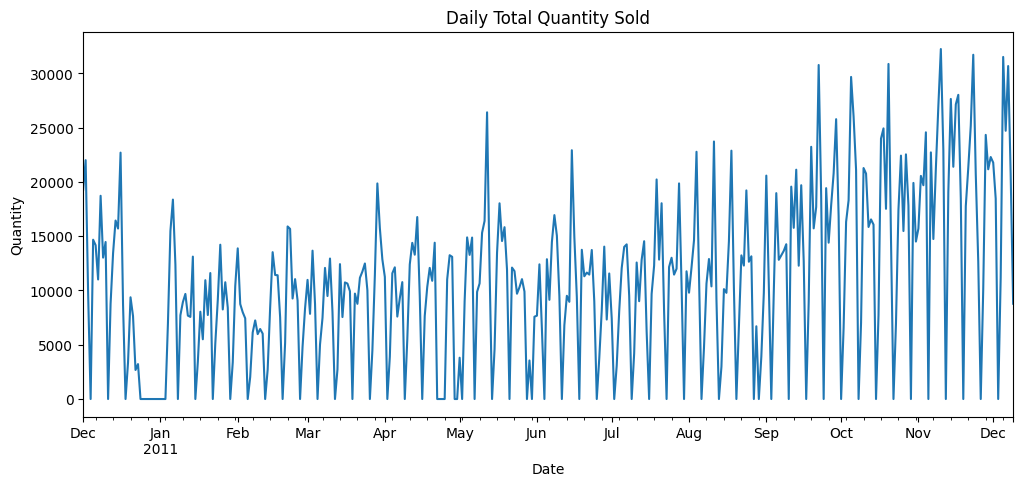

In [11]:
plt.figure(figsize=(12,5))
daily_sales.plot()
plt.title("Daily Total Quantity Sold")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.show()

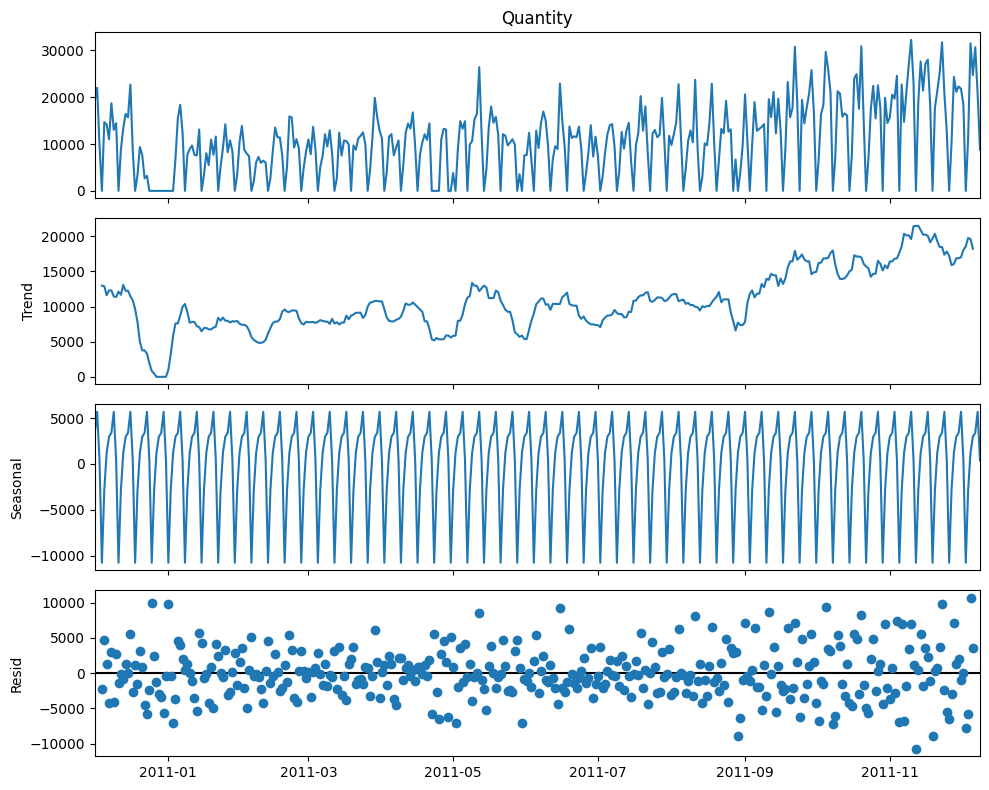

In [12]:
decomposition = seasonal_decompose(daily_sales, model="additive", period=7)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

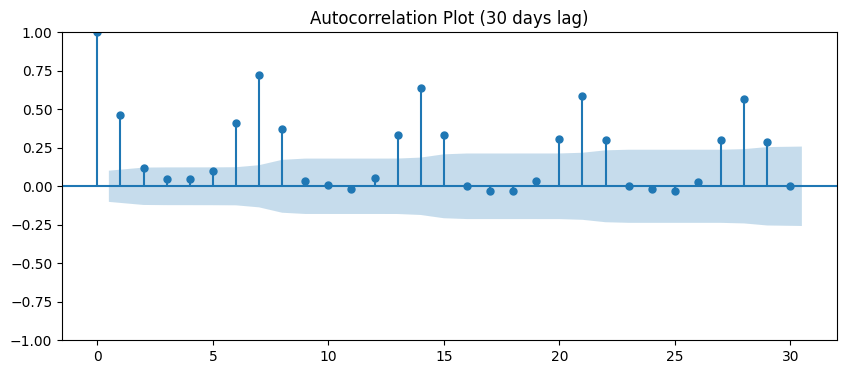

In [13]:
fig, ax = plt.subplots(figsize=(10,4))
plot_acf(daily_sales, lags=30, ax=ax)
plt.title("Autocorrelation Plot (30 days lag)")
plt.show()

In [14]:
train = daily_sales[:-14]
test = daily_sales[-14:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 360
Test size: 14


In [15]:
arima_model = ARIMA(train, order=(2,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=14)
print(arima_forecast)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2011-11-26    14020.739133
2011-11-27    18354.606999
2011-11-28    21694.999537
2011-11-29    22368.151778
2011-11-30    21077.472598
2011-12-01    19460.041632
2011-12-02    18667.066304
2011-12-03    18847.577953
2011-12-04    19477.821067
2011-12-05    19973.212896
2011-12-06    20080.261740
2011-12-07    19895.718390
2011-12-08    19658.211195
2011-12-09    19538.888034
Freq: D, Name: predicted_mean, dtype: float64


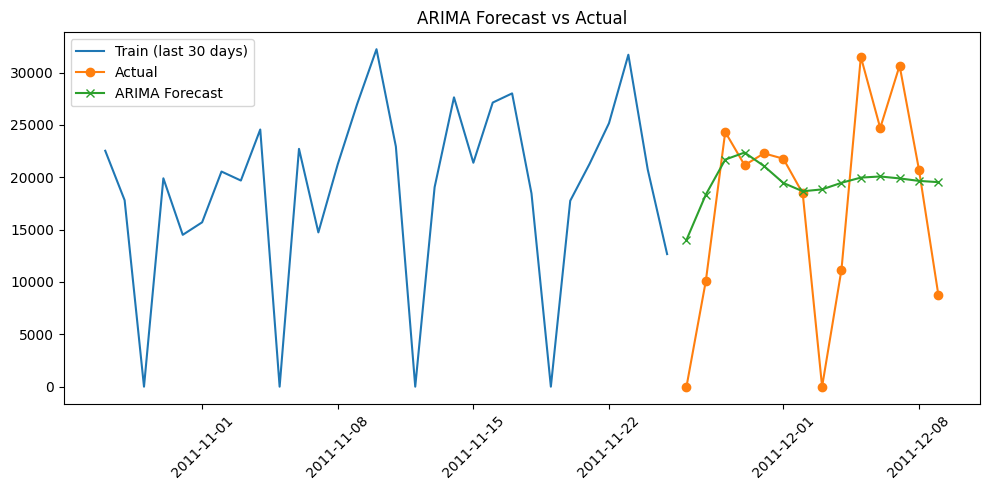

In [16]:
plt.figure(figsize=(10,5))
plt.plot(train.index[-30:], train.values[-30:], label="Train (last 30 days)")
plt.plot(test.index, test.values, label="Actual", marker="o")
plt.plot(test.index, arima_forecast.values, label="ARIMA Forecast", marker="x")
plt.legend()
plt.title("ARIMA Forecast vs Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
prophet_df = train.reset_index()
prophet_df.columns = ["ds", "y"]

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=14)
prophet_forecast = prophet_model.predict(future)


prophet_pred = prophet_forecast.set_index("ds")["yhat"][-14:]
prophet_pred


INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


,yhat
ds,
2011-11-26,7901.059402
2011-11-27,15754.510289
2011-11-28,19343.481229
2011-11-29,21394.156180
2011-11-30,22073.126396
2011-12-01,24456.591412
2011-12-02,19072.223079
2011-12-03,8354.066476
2011-12-04,16207.517364


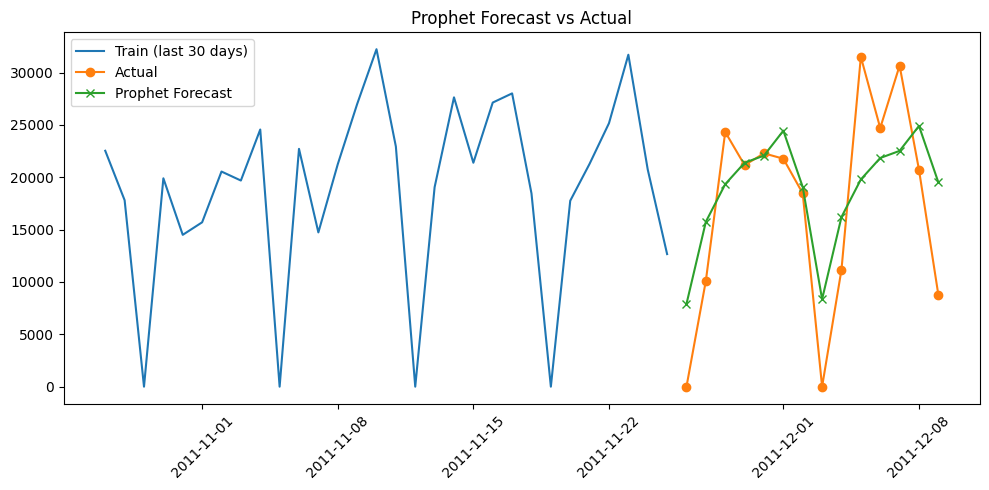

In [18]:
plt.figure(figsize=(10,5))
plt.plot(train.index[-30:], train.values[-30:], label="Train (last 30 days)")
plt.plot(test.index, test.values, label="Actual", marker="o")
plt.plot(test.index, prophet_pred.values, label="Prophet Forecast", marker="x")
plt.legend()
plt.title("Prophet Forecast vs Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
def safe_mape(actual, predicted):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

# ARIMA scores
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = safe_mape(test.values, arima_forecast.values)

# Prophet scores
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_pred))
prophet_mape = safe_mape(test.values, prophet_pred.values)

results = pd.DataFrame({
    "Model": ["ARIMA", "Prophet"],
    "RMSE": [arima_rmse, prophet_rmse],
    "MAPE (%)": [arima_mape, prophet_mape]
})

results

,Model,RMSE,MAPE (%)
0,ARIMA,8829.927493,33.979169
1,Prophet,6361.806090,29.741359


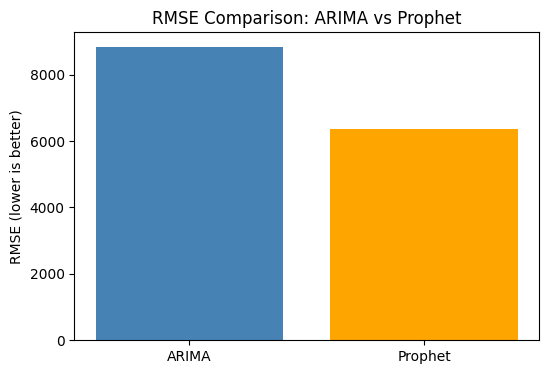

In [20]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"], color=["steelblue", "orange"])
plt.title("RMSE Comparison: ARIMA vs Prophet")
plt.ylabel("RMSE (lower is better)")
plt.show()